# Introduction to Neural Network Classification with TensorFlow

## Creating data to view and fit

In [ ]:
from sklearn.datasets import make_circles
import tensorflow as tf
import pandas as pd

# make 1000 examples
n_samples = 1000

# Create circles
X, Y = make_circles(
    n_samples,
    noise=0.03,
    random_state=42
)

In [ ]:
# check out features
X[:10]

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       [-0.39373073,  0.69288277],
       [ 0.44220765, -0.89672343],
       [-0.47964637,  0.67643477],
       [-0.01364836,  0.80334872],
       [ 0.77151327,  0.14775959],
       [-0.16932234, -0.79345575],
       [-0.1214858 ,  1.02150905]])

In [ ]:
# check the labels
Y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

## Input and Output shapes of our features and labels

In [ ]:
# Check the shapes of features and labels
X.shape, Y.shape

((1000, 2), (1000,))

## Building a model

In [ ]:
# Create a test and train split
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(800, 2)

In [ ]:
tf.random.set_seed(42)

# Create model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# compile the model
model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer = tf.keras.optimizers.Adam(0.03),
              metrics=["accuracy"])

# fit the model
history = model.fit(X_train, Y_train, epochs=200, verbose=0)

In [ ]:
model.evaluate(X_test, Y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0042  


[0.004160857759416103, 1.0]

<Axes: >

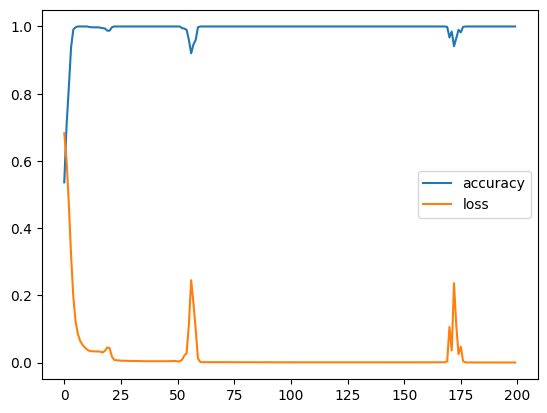

In [ ]:
pd.DataFrame(history.history).plot()

In [ ]:
import tensorflow as tf

tf.random.set_seed(42)

# Introduce a callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)

# Create a model
model_ = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model_.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(0.01),
              metrics=["accuracy"])
history_ = model_.fit(X_train, Y_train, epochs=200, verbose=0, callbacks=[early_stopping])

In [ ]:
model_.evaluate(X_test, Y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9950 - loss: 0.0104  


[0.010401484556496143, 0.9950000047683716]

<Axes: >

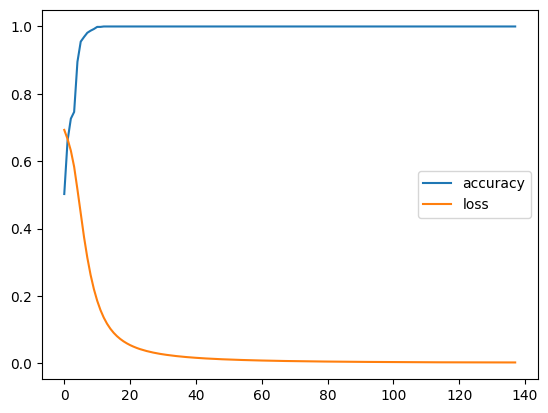

In [ ]:
# Plot the loss curve
import pandas as pd

pd.DataFrame(history_.history).plot()

In [ ]:
model_.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,205 (4.71 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 804 (3.14 KB)

In [ ]:
# Visualize the models prediction
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(model, x, y):
  """Plot the decision boundary created by a model predicting on X"""
  # Define the axis boundaries of the plot and create a meshgrid
  x_min, x_max = x[:, 0].min() - 0.1, x[:, 0].max() + 0.1
  y_min, y_max = x[:, 1].min() - 0.1, x[:, 1].max() + 0.1
  # Create the meshgrid
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                       np.linspace(y_min, y_max, 100))

  # Create X value (we're going to make predictions)
  x_in = np.c_[xx.ravel(), yy.ravel()]

  # make predictions
  y_pred = model.predict(x_in)

  # check for multi-class
  if len(y_pred[0]) > 1:
    print("Doing multi-class classification")
    # we would have to reshape our prediction to get them ready for plotting
    y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
  else:
    print("Doing Binary Classification")
    y_pred = np.round(y_pred).reshape(xx.shape)

  # Plot the decision boundary
  plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
  plt.scatter(x[:, 0], x[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Doing Binary Classification


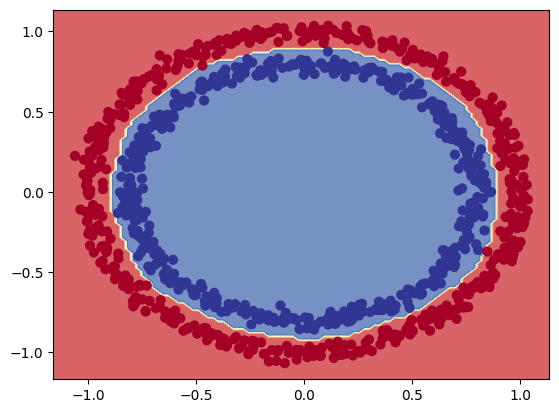

In [ ]:
# Check out the predictions our model is making
plot_decision_boundary(model, X, Y)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Doing Binary Classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Doing Binary Classification


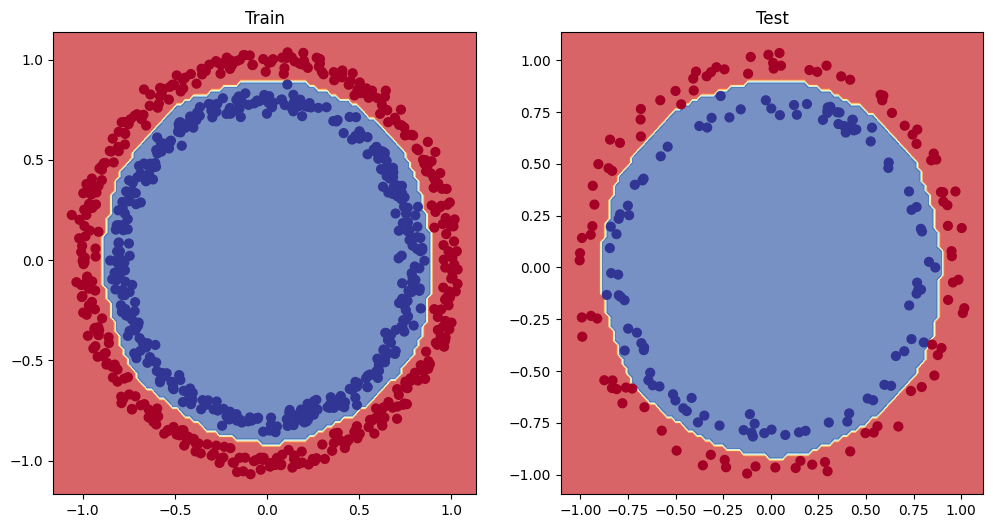

In [ ]:
# Plot the decision boundaries for the training and the test dataset
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, Y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, Y_test)

## Non-linearity


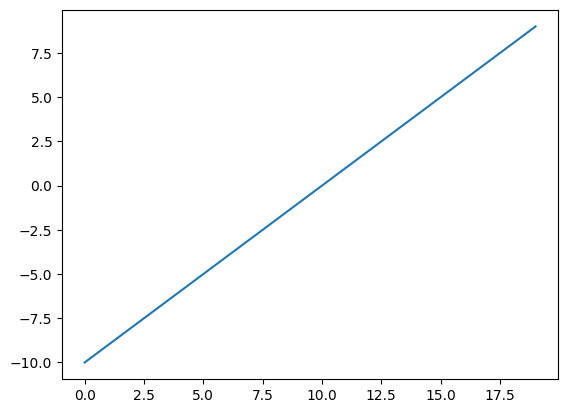

In [ ]:
# Create a toy tensor
A = tf.cast(tf.range(-10, 10), tf.float32)
plt.plot(A)

In [ ]:
# Let's start by replicating sigmoid = 1 / (1 + exp(-x))
def sigmoid(x):
  return 1 / (1 + tf.exp(-x))

# Use the sigmoid function on our toy sensor
sigmoid(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([4.5397872e-05, 1.2339458e-04, 3.3535014e-04, 9.1105117e-04,
       2.4726233e-03, 6.6928510e-03, 1.7986210e-02, 4.7425874e-02,
       1.1920292e-01, 2.6894143e-01, 5.0000000e-01, 7.3105860e-01,
       8.8079703e-01, 9.5257413e-01, 9.8201376e-01, 9.9330717e-01,
       9.9752742e-01, 9.9908900e-01, 9.9966466e-01, 9.9987662e-01],
      dtype=float32)>

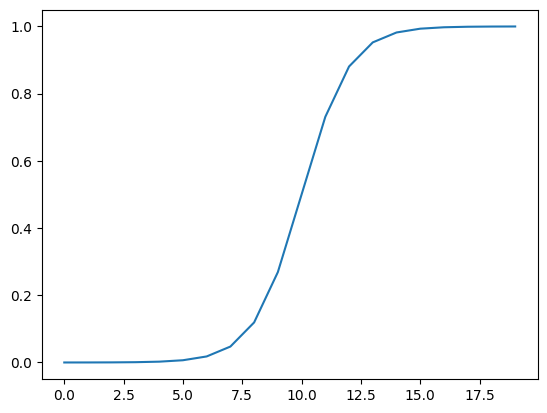

In [ ]:
# Plot our toy tensor
plt.plot(sigmoid(A))

### Finding the ideal learning rate

The learning rate where the loss decreases the most during training

In [ ]:
# Set random seed
tf.random.set_seed(42)

# Create model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# compile the model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy,
                optimizer=tf.keras.optimizers.Adam(0.01),
                metrics=["accuracy"])

# Create a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

# fit the model(passinf the lr_scheduler callback)
history = model_1.fit(X_train, Y_train, epochs=100, callbacks=[lr_scheduler], verbose=0)

<Axes: >

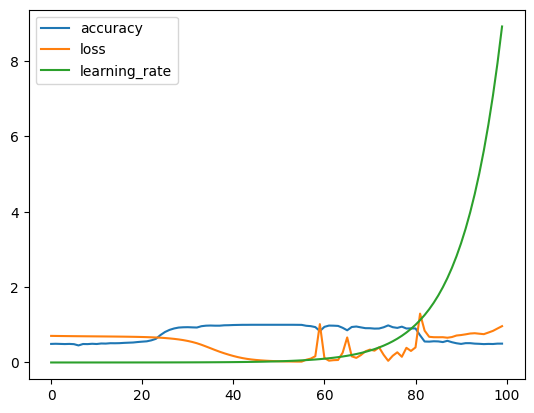

In [ ]:
# Check history
pd.DataFrame(history.history).plot()

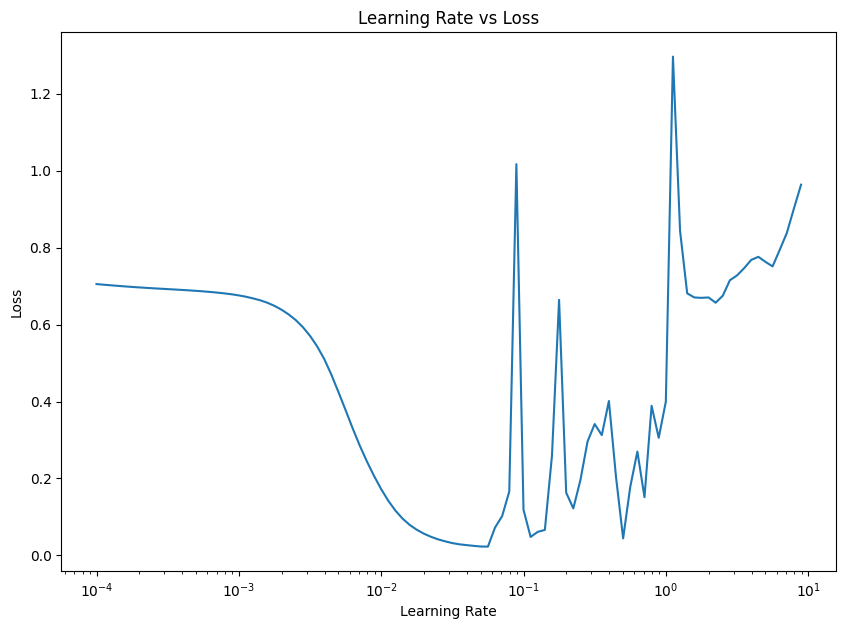

In [ ]:
# Plot the learning rate against the loss
lrs = 1e-4 * (10**(tf.range(100)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history.history['loss'])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning Rate vs Loss");

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Doing Binary Classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Doing Binary Classification


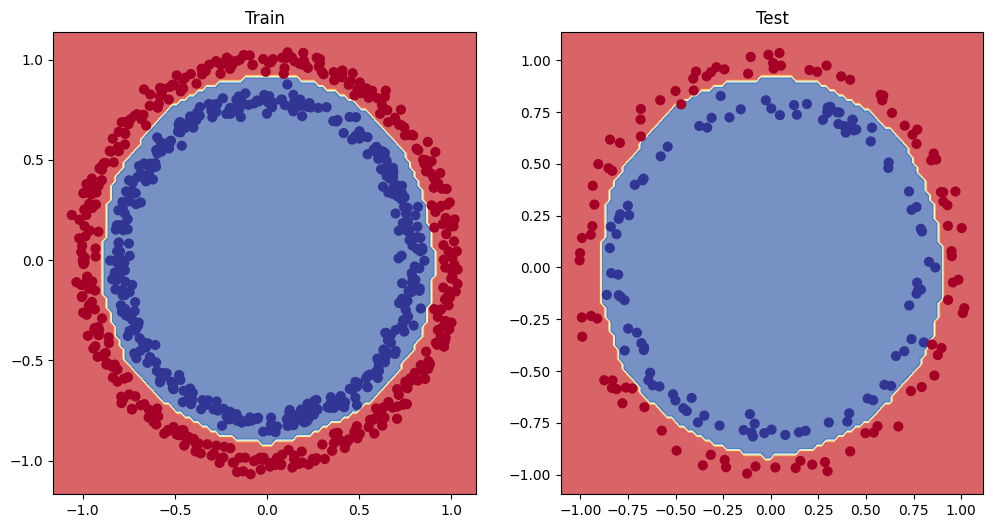

In [ ]:
# Plot the decision boundaries for the training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_, X_train, Y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_, X_test, Y_test)

## Evaluating our model
We'l be evaluating our model using evaluation metrics such as:

1). Accuracy

2). Precision

3). Recall

4). F1 Score

5). Confusion Matrix

6). Classification Report

In [ ]:
# Check the accuracy of our model
loss, accuracy = model_.evaluate(X_test, Y_test)
print(f"Model loss on the test set: {loss}")
print(f"Model accuracy on the test set: {(accuracy*100):.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9950 - loss: 0.0104 
Model loss on the test set: 0.010401484556496143
Model accuracy on the test set: 99.50%


### Confusion matrix

In [ ]:
# Create a confusion matrix
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
y_pred = tf.round(y_pred)
cm = confusion_matrix(Y_test, y_pred)
cm

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


array([[100,   0],
       [  0, 100]])

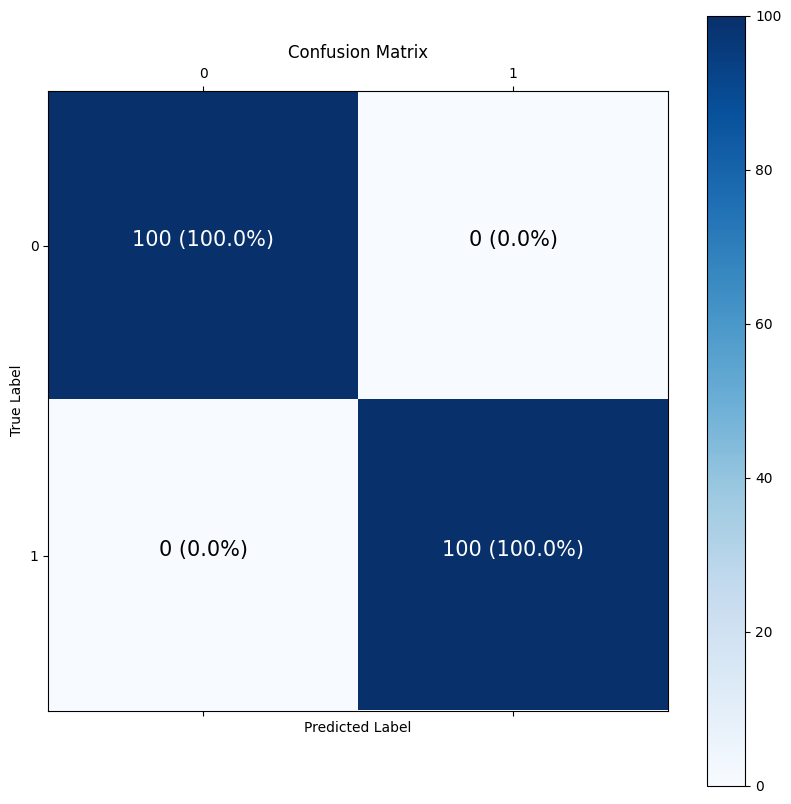

In [ ]:
# Prettify the confusion matrix
import itertools

figsize = (10, 10)
# Normalize our confusion matrix
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
n_classes = cm.shape[0]
#  let's pretify it
fig, ax = plt.subplots(figsize=figsize)
# Create a matrix plot
cax = ax.matshow(cm, cmap=plt.cm.Blues)
fig.colorbar(cax)

# Create classes
classes = False

if classes:
  labels=classes
else:
  labels = np.arange(cm.shape[0])
# Label the axes
ax.set(title="Confusion Matrix",
       xlabel="Predicted Label",
       ylabel="True Label",
       xticks=np.arange(n_classes),
       yticks=np.arange(n_classes),
       xticklabels=labels,
       yticklabels=labels)

# Set threshold for different colors
threshold = (cm.max() + cm.min()) / 2

# Plot the text on each cell
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
  plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
  horizontalalignment="center",
           color="white" if cm[i, j] > threshold else "black",
           size=15)